# Part 1 - Loan-risk EDA and LightGBM baseline

This notebook documents the reproducible Part 1 workflow: source validation, target definition, application-time feature selection, Clarity coverage, chronological splitting, held-out evaluation, overfitting checks, feature importance, calibration, and limitations.

**Prediction:** probability that a funded loan reaches an adverse terminal outcome, using only information available before pricing. Payment data, `apr`, and `originallyScheduledPaymentAmount` are excluded from model inputs because the score may inform APR and loan terms.

In [1]:
from pathlib import Path
import json
import os
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score, brier_score_loss, confusion_matrix,
    ConfusionMatrixDisplay, log_loss, roc_auc_score,
)

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Run this notebook from the repository or notebooks directory')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.data import join_clarity, load_training_inputs
from src.features import build_features
from src.labels import (
    create_resolved_target, find_unfunded_terminal_outcomes, target_distribution,
)
from src.train import temporal_split

get_ipython().run_line_magic('matplotlib', 'inline')
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')
CONFIG_PATH = Path('configs/baseline.yaml')
ARTIFACT_DIR = Path('artifacts/prepricing_lightgbm')
config = yaml.safe_load(CONFIG_PATH.read_text())

## 1. Load and validate application-time sources

The training path loads the loan-application table and Clarity underwriting reports only. The payment table belongs to a separate outcome-audit workflow and is intentionally absent here.

In [2]:
loans, clarity = load_training_inputs(config)
quarantined = find_unfunded_terminal_outcomes(loans, config)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', UserWarning)
    resolved = create_resolved_target(loans, config)
joined = join_clarity(resolved, clarity)

source_summary = pd.DataFrame([
    {'dataset': 'loan applications', 'rows': len(loans), 'columns': loans.shape[1]},
    {'dataset': 'Clarity reports', 'rows': len(clarity), 'columns': clarity.shape[1]},
    {'dataset': 'resolved modelling population', 'rows': len(resolved), 'columns': resolved.shape[1]},
])
source_summary

,dataset,rows,columns
0,loan applications,573402,19
1,Clarity reports,49596,54
2,resolved modelling population,28360,20


## 2. Source outcomes and target definition

The supplied brief does not formally define loan risk. The primary baseline uses `adverse_outcome = 1` for Internal Collection, External Collection, Settled Bankruptcy, or Charged Off, and `0` only for Paid Off Loan. Unfunded, unresolved, voided, and ambiguous outcomes are excluded. `Settlement Paid Off` and `Charged Off Paid Off` are not defined in the supplied dictionary and are excluded rather than assigned an unsupported label.

In [3]:
status_counts = (
    loans['loanStatus'].astype('string').fillna('<missing>')
    .value_counts().rename_axis('loanStatus').to_frame('rows')
)
display(status_counts.head(15))

target_summary = target_distribution(resolved, config['label']['target_name'])
target_summary

,rows
loanStatus,
Withdrawn Application,448133
Rejected,84101
Paid Off Loan,11349
External Collection,11231
New Loan,7985
Internal Collection,5458
Returned Item,1173
CSR Voided New Loan,1016
Settlement Paid Off,701


{'rows': 28360,
 'negative_count': 11349,
 'positive_count': 17011,
 'positive_rate': 0.5998236953455571}

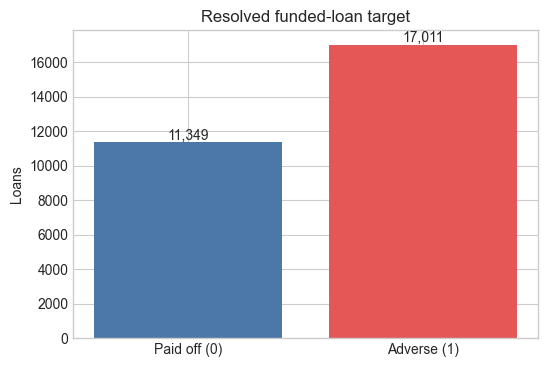

In [4]:
target_counts = resolved['adverse_outcome'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Paid off (0)', 'Adverse (1)'], target_counts.reindex([0, 1]), color=['#4C78A8', '#E45756'])
ax.set(title='Resolved funded-loan target', ylabel='Loans')
for i, value in enumerate(target_counts.reindex([0, 1])):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom')
plt.show()

## 3. Data-quality quarantine

Terminal repayment outcomes should occur only on funded loans. The pipeline reports and removes contradictions instead of silently correcting them.

In [5]:
quarantine_columns = [
    'loanId', 'applicationDate', 'originated', 'approved',
    'isFunded', 'loanStatus', 'fpStatus',
]
quarantined[quarantine_columns].sort_values('applicationDate')

,loanId,applicationDate,originated,approved,isFunded,loanStatus,fpStatus
500117,LL-I-04896680,2015-11-22T22:55:09.262000,False,False,0,Settled Bankruptcy,No Payments
458547,LL-I-17430751,2017-02-20T14:33:46.154000,False,False,0,Internal Collection,NaN
133774,LL-I-17810513,2017-03-01T04:13:19.576000,False,False,0,Internal Collection,NaN
264078,LL-I-17931830,2017-03-03T16:20:53.598000,False,False,0,Internal Collection,NaN


## 4. Clarity report coverage

Clarity is application-time underwriting information. The join is left-sided and many-to-one: eligible loans without a report remain in the population, with missing values and an explicit `has_clarity_report` indicator.

In [6]:
coverage_by_lead = (
    joined.groupby('leadType', observed=True)
    .agg(
        loans=('loanId', 'size'),
        adverse_rate=('adverse_outcome', 'mean'),
        clarity_coverage=('has_clarity_report', 'mean'),
    )
    .sort_values('loans', ascending=False)
)
display(coverage_by_lead.style.format({'adverse_rate': '{:.1%}', 'clarity_coverage': '{:.1%}'}))
print(f"Overall Clarity coverage: {joined['has_clarity_report'].mean():.1%}")

,loans,adverse_rate,clarity_coverage
leadType,,,
bvMandatory,13444,68.0%,86.6%
lead,7006,63.9%,95.9%
organic,5905,42.9%,67.6%
prescreen,1061,54.3%,99.7%
rc_returning,877,30.1%,8.0%
california,37,43.2%,100.0%
express,10,10.0%,10.0%
lionpay,10,0.0%,20.0%
repeat,9,33.3%,11.1%


Overall Clarity coverage: 83.0%


In [7]:
clarity_feature_columns = [
    column for column in clarity.columns
    if column not in {'underwritingid', '__index_level_0__'}
]
missingness = (
    joined[clarity_feature_columns].isna().mean()
    .sort_values(ascending=False).head(15)
    .rename('missing_rate').to_frame()
)
missingness.style.format({'missing_rate': '{:.1%}'})

,missing_rate
.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonetype,97.3%
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncodedescription,95.6%
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncode,95.6%
.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncode,90.9%
.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncodedescription,90.9%
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobreasoncode,84.6%
.underwritingdataclarity.clearfraud.clearfraudindicator.driverlicenseinconsistentwithonfile,83.6%
.underwritingdataclarity.clearfraud.clearfraudindicator.workphonepreviouslylistedashomephone,51.0%
.underwritingdataclarity.clearfraud.clearfraudindicator.workphonepreviouslylistedascellphone,51.0%
.underwritingdataclarity.clearfraud.clearfraudindicator.driverlicenseformatinvalid,27.2%


## 5. Temporal behaviour and split

A chronological split better simulates production than a random split: the model learns from older loans and is evaluated on newer mature outcomes. It also exposes changes in acquisition, underwriting policy, and borrower behaviour. The newest loans still require enough outcome maturity; this dataset lacks a formal performance window, so that remains a limitation.

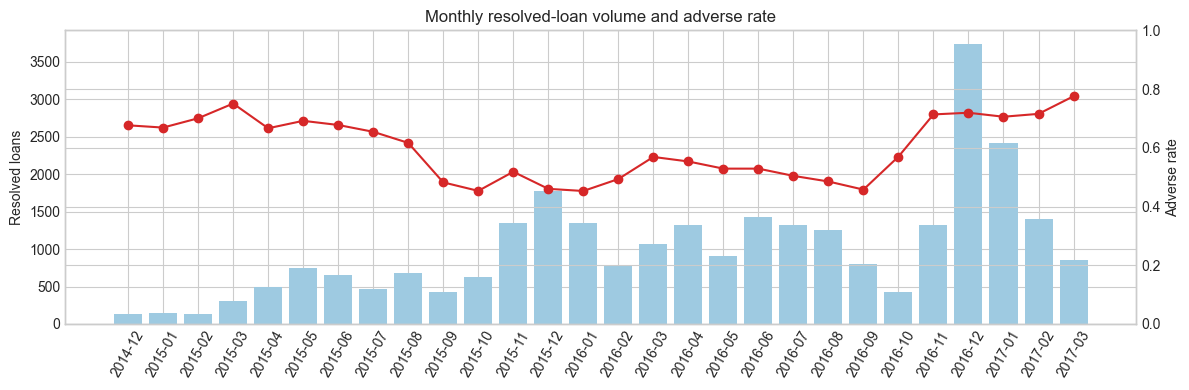

In [8]:
monthly = joined.assign(
    application_month=pd.to_datetime(joined['applicationDate'], format='mixed', utc=True).dt.strftime('%Y-%m')
).groupby('application_month').agg(
    loans=('loanId', 'size'), adverse_rate=('adverse_outcome', 'mean')
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(monthly.index, monthly['loans'], color='#9ECAE1', label='Loans')
ax1.set_ylabel('Resolved loans')
ax1.tick_params(axis='x', rotation=60)
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['adverse_rate'], color='#D62728', marker='o', label='Adverse rate')
ax2.set_ylabel('Adverse rate')
ax2.set_ylim(0, 1)
ax1.set_title('Monthly resolved-loan volume and adverse rate')
fig.tight_layout()
plt.show()

In [9]:
train_frame, valid_frame, test_frame = temporal_split(
    joined, config['split']['validation_fraction'], config['split']['test_fraction']
)
split_summary = pd.DataFrame([
    {'split': name, 'rows': len(frame), 'start': frame['applicationDate'].min(),
     'end': frame['applicationDate'].max(), 'adverse_rate': frame['adverse_outcome'].mean()}
    for name, frame in [('train', train_frame), ('validation', valid_frame), ('test', test_frame)]
])
split_summary.style.format({'adverse_rate': '{:.1%}'})

,split,rows,start,end,adverse_rate
0,train,18433,2014-12-03T00:39:02.866000,2016-10-19T16:30:45.477000,53.6%
1,validation,4255,2016-10-19T16:37:32.465000,2016-12-19T16:38:23.835000,72.0%
2,test,5672,2016-12-19T16:38:40.512000,2017-03-18T23:34:27.369000,71.6%


## 6. Load the fitted baseline and reproduce predictions

LightGBM builds decision trees sequentially, with each tree correcting errors made by earlier trees. The configuration permits up to 1,000 iterations, but validation-based early stopping selects the best iteration. The test period is not used to fit trees or choose the stopping point.

In [10]:
model = joblib.load(ARTIFACT_DIR / 'model.joblib')
saved_metrics = json.loads((ARTIFACT_DIR / 'metrics.json').read_text())
saved_metadata = json.loads((ARTIFACT_DIR / 'data_cutoff.json').read_text())
feature_names = json.loads((ARTIFACT_DIR / 'features.json').read_text())

split_data = {}
for name, frame in [('train', train_frame), ('validation', valid_frame), ('test', test_frame)]:
    X, y = build_features(
        frame, config['label']['target_name'], config.get('feature_contract', {})
    )
    X = X[feature_names]
    split_data[name] = (X, y, model.predict_proba(X)[:, 1])

pd.Series({
    'best_iteration': model.best_iteration_,
    'feature_count': len(feature_names),
    'test_roc_auc': saved_metrics['roc_auc'],
    'test_pr_auc': saved_metrics['pr_auc'],
    'test_log_loss': saved_metrics['log_loss'],
})

best_iteration    36.000000
feature_count     63.000000
test_roc_auc       0.736793
test_pr_auc        0.849417
test_log_loss      0.614929
dtype: float64

## 7. Overfitting and held-out performance

A large gap between training and validation/test performance would suggest overfitting. The final reported metrics come from the untouched chronological test period.

In [11]:
performance_rows = []
for name, (_, y, probabilities) in split_data.items():
    performance_rows.append({
        'split': name,
        'rows': len(y),
        'roc_auc': roc_auc_score(y, probabilities),
        'pr_auc': average_precision_score(y, probabilities),
        'log_loss': log_loss(y, probabilities),
        'brier_score': brier_score_loss(y, probabilities),
    })
performance = pd.DataFrame(performance_rows).set_index('split')
display(performance.style.format({column: '{:.4f}' for column in performance.columns if column != 'rows'}))
roc_gap = performance.loc['train', 'roc_auc'] - performance.loc['test', 'roc_auc']
print(f"Train-to-test ROC-AUC gap: {roc_gap:.4f}. The modest gap does not indicate severe overfitting, but the lower test ROC-AUC supports temporal drift monitoring.")

,rows,roc_auc,pr_auc,log_loss,brier_score
split,,,,,
train,18433,0.7224,0.7326,0.6317,0.2200
validation,4255,0.7553,0.8694,0.6211,0.2147
test,5672,0.7368,0.8494,0.6149,0.2117


Train-to-test ROC-AUC gap: -0.0144. The modest gap does not indicate severe overfitting, but the lower test ROC-AUC supports temporal drift monitoring.


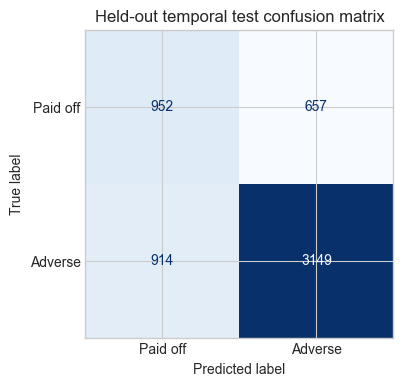

In [12]:
_, y_test, test_probabilities = split_data['test']
test_predictions = (test_probabilities >= config['evaluation']['threshold']).astype(int)
matrix = confusion_matrix(y_test, test_predictions, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(matrix, display_labels=['Paid off', 'Adverse']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Held-out temporal test confusion matrix')
plt.show()

## 8. Feature importance

Gain importance measures how much each feature improved the tree objective when selected. It is useful for model inspection but is not causal evidence; correlated features can divide importance between themselves.

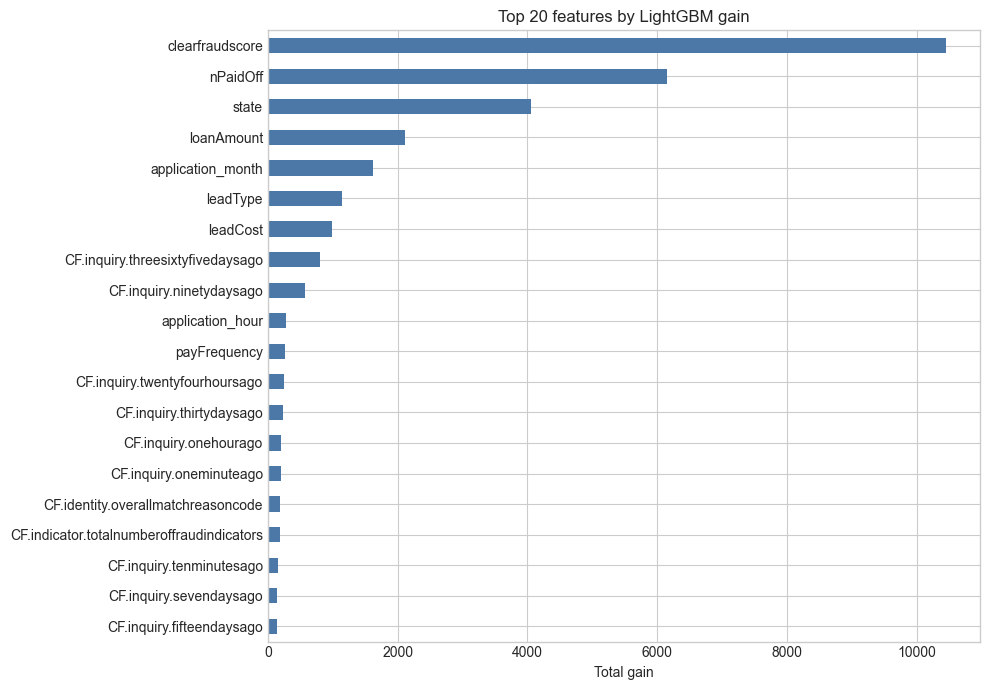

,gain
clearfraudscore,10454.725268
nPaidOff,6160.310502
state,4058.863486
loanAmount,2112.212049
application_month,1613.598891
leadType,1136.679216
leadCost,995.574659
.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago,802.527358
.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago,579.842858
application_hour,275.267691


In [13]:
importance = (
    pd.Series(model.booster_.feature_importance(importance_type='gain'), index=feature_names)
    .sort_values(ascending=False).head(20).sort_values()
)
def shorten_feature_name(name):
    return (name
            .replace('.underwritingdataclarity.clearfraud.', 'CF.')
            .replace('clearfraudinquiry.', 'inquiry.')
            .replace('clearfraudindicator.', 'indicator.')
            .replace('clearfraudidentityverification.', 'identity.'))
plot_importance = importance.rename(index=shorten_feature_name)
fig, ax = plt.subplots(figsize=(10, 7))
plot_importance.plot.barh(ax=ax, color='#4C78A8')
ax.set(title='Top 20 features by LightGBM gain', xlabel='Total gain')
fig.tight_layout()
plt.show()
importance.sort_values(ascending=False).to_frame('gain').head(10)

## 9. Probability calibration and decision threshold

Ranking metrics such as ROC-AUC do not guarantee that a predicted 70% risk corresponds to a 70% observed adverse rate. The calibration plot checks that relationship. The 0.50 classification threshold is a baseline convention, not a business-optimal lending rule.

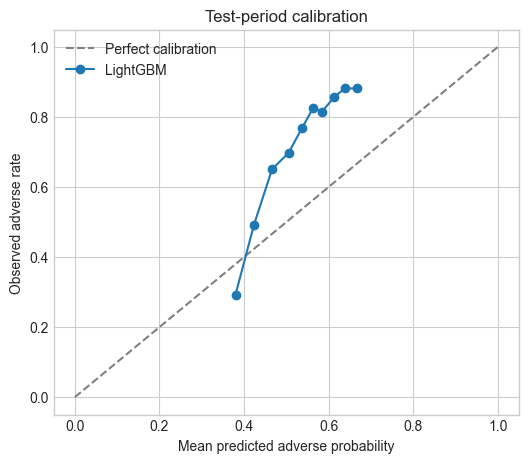

Test Brier score: 0.2117


In [14]:
observed_rate, mean_probability = calibration_curve(
    y_test, test_probabilities, n_bins=10, strategy='quantile'
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax.plot(mean_probability, observed_rate, marker='o', label='LightGBM')
ax.set(xlabel='Mean predicted adverse probability', ylabel='Observed adverse rate',
       title='Test-period calibration')
ax.legend()
plt.show()
print(f'Test Brier score: {brier_score_loss(y_test, test_probabilities):.4f}')

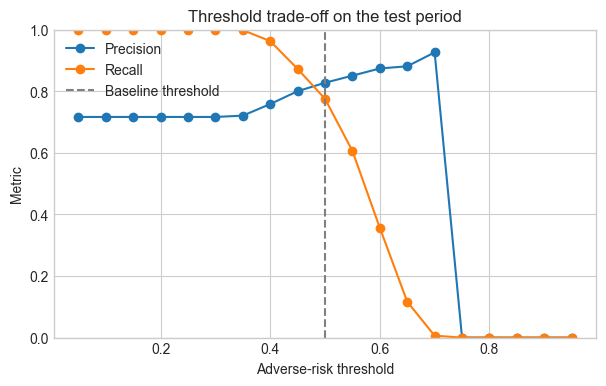

In [15]:
thresholds = pd.read_json(ARTIFACT_DIR / 'threshold_analysis.json')
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds['threshold'], thresholds['precision'], marker='o', label='Precision')
ax.plot(thresholds['threshold'], thresholds['recall'], marker='o', label='Recall')
ax.axvline(config['evaluation']['threshold'], color='gray', linestyle='--', label='Baseline threshold')
ax.set(xlabel='Adverse-risk threshold', ylabel='Metric', ylim=(0, 1),
       title='Threshold trade-off on the test period')
ax.legend()
plt.show()

## 10. Conclusions and limitations

- The baseline uses 28,360 funded loans with unambiguous resolved outcomes; ambiguous settlement/charged-off-paid-off statuses are excluded.
- Four unfunded loans carry contradictory terminal statuses and are quarantined.
- Clarity is valid application-time underwriting information and is left-joined; payment outcomes are never model features.
- The primary `pre_pricing_v1` contract excludes APR and scheduled payment to avoid requiring terms that may be created from the risk score.
- Chronological train/validation/test periods simulate future deployment and expose drift better than a random split.
- The reported test metrics are held out from fitting and early stopping.
- Feature importance is associative, not causal. `leadType` can represent acquisition and historical underwriting policy.
- The target is observable only for historically funded loans, creating approval-selection bias.
- The source lacks a formal outcome window, so maturity/censoring of recent loans remains a limitation.
- The 0.50 threshold must eventually be replaced by a business-cost decision rule and probability calibration should be monitored.
- Parts 2 and 3 should automate maturity checks, drift detection, retraining, champion-challenger gates, registration, deployment, monitoring, and rollback.